## MLOps of Salary Prediction Classification

In [ ]:
!pip install -r requirements.txt

^C


In [ ]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif

run = wandb.init(
    project="MLOps_Salary_Prediction",
    config={
        "architecture": "MLP",
        "dataset": "Adult Income",
        "test_size": 0.2,
        "random_state": 42
    }
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\josem\_netrc.
wandb: Currently logged in as: moiseslopesdasilva708811 (moiseslopesdasilva708811-ufrn) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Visualização inicial do Dataset

Utilizei nesta etapa, uma análise das dimensões dos dados e como estavam disponíveis para acesso por meio de variáveis ambiente no arquivo .csv em questão, usando a biblioteca Pandas para saber de informações como as primeiras 5 linhas do dataset pelo comando df.head() da mesma biblioteca, para ter uma noção dos principais dados retratados nessas principais linhas do conjunto de dados, onde o Dataset mostrou com precisão os dados que deveriam ser analisados e comparados com base num gráfico de correlação e um histograma para mostrar os causadores de impacto salarial, entre outros.

Após a Leitura inicial dos dados, foi possível verificar por meio do comando df.shape() o tamanho total do dataset com base no volume de informações armazenados, contendo 32.561 linhas e 15 colunas de informação, o que posteriormente trouxe à tona que seria precivo fazer uma limpeza no conjunto de informações e ver se não estava em falta algum conjunto de informações necessário para a modelagem inicial do modelo de Predição Salarial.

Em seguida, o comando que mais trouxe informações para meus estudos iniciais foi sem dúvidas, o df.describe(), para mostrar a distribuição salarial de acordo com a idade, tendo uma média demostrada na tabela por 38,5. Além desse dado de faixa etária na base dados, é possível analisar que desse público analisado, as pessoas que estão envolvidas na correlação são pessoas com idade entre 17 e 90 anos, sendo uma dessas o mínimo e a outra o máximo da função em que posteriormente os estudos apontariam para quanto cada pessoa ganha por faixa etária. Na coluna education-num, é possível ver também a quantidade em anos que as pessoas na análise estudaram, indo do mínimo que é 1 ano até o máximo que são 16 anos de estudo. O ganho monetário real da população pode ser estudado olhando para o dado previsto na coluna capital-gain que se perpassa em 75% onde nessa porcentagem ninguém possui uma fonte de renda, mas quem ganha dinheiro nessa população, ganha muito. Da mesma forma é possível analisar em capital-loss, onde a maioria é 0 e alguns poucos valores altos. Como analisado também na coluna hours-per-week, é possível ver a média de trabalho dos indivíduos no conjunto de dados sendo igual a 40h/semana, a mediana também sendo igual a 40h/semana e o máximo de 99h/semana.

Primeiras linhas do Dataset
   age          workclass  fnlwgt   education  education-num  \
0   39          State-gov   77516   Bachelors             13   
1   50   Self-emp-not-inc   83311   Bachelors             13   
2   38            Private  215646     HS-grad              9   
3   53            Private  234721        11th              7   
4   28            Private  338409   Bachelors             13   

        marital-status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   capital-gain  capital-loss  hours-per-week  native-country  salary  
0          2174             0           

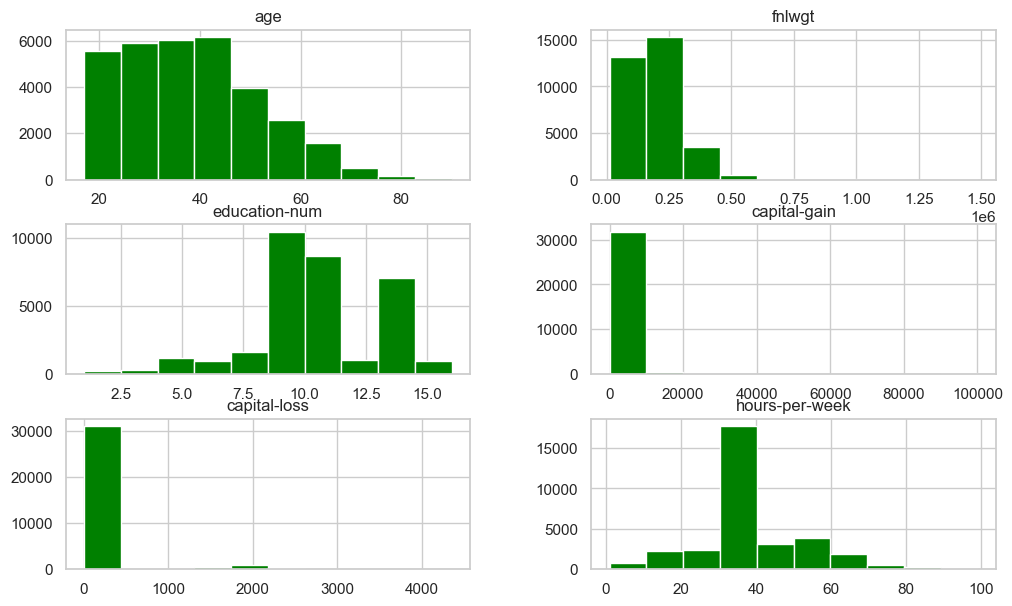

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import wandb
df = pd.read_csv("C:/Users/josem/OneDrive/Documentos/MLOPs_Salary_Prediction/data/salary.csv") # Pasta em que se encontra o meu arquivo salary.csv

print("Primeiras linhas do Dataset")
print(df.head()) #  Mostra as primeiras linhas do Dataset

print("\n Formato do Dataset")
print(df.shape) # Tamanho total do Dataset com o total de linhas por coluna

print("\n Informações")
df.info() # Informações

print("\n Estatísticas")
print(df.describe())

print("\n Valores Faltantes:")
print(df.isin(["?"]).sum()) # valor que pode não está armazenado
print(df.isnull().sum())
print("Distribuição de variável alvo")
print(df['salary'].value_counts(normalize=True))

df.hist(figsize=(12,7), color="green") 
plt.savefig("histogramas.png", dpi=300, bbox_inches='tight')
plt.show() 

Por último, com a limpeza de valores nulos(null), foi estudado os métodos de plotar os gráficos em histogramas inicias dessa análise, implementados com o auxílio da biblioteca matplotlib e do mecanismo plt.hist(), o que se configura como importante para uma abstração melhor de como os dados impactam na vida financeira das pessoas estudadas, como os dados de idade(age), peso estatístico imaginário ~189 mil que representa apenas uma estimativa não real(fnlwgt) que geralmente não ajuda muito no modelo de MLOps então foi descartado da análise. Já sobre dados ainda mais específicos do indivíduo, são possíveis de serem mencionados os dados raciais (race), sexuais (sex), de estado civil (marital-status), o tipo de emprego(workclass), o país em que reside(native-country) e o grau de estudo (education) e como todos esses dados se relacionam direta ou indiretamente à coluna salary. Todos esses dados são possíveis de serem vistos na tabela gerada pelo df.describe(), um simples comando que trouxe real sentido nos estudos dos dados. Nesse meu processo, fiz uma pesquisa de como salvar as imagens em meu próprio notebook, com ajuda do comando plt.savefig()


Com esses conjunto de dados analisados, o próximo indicativo estudado na biblioteca pandas foi a limpeza de dados faltantes, onde foi utilizado um método chamado df.isin(["?"]).sum() que encontra valores nulos, ou seja, valores que não foram digitados e depois por meio do comando df.isnull().sum() apaga a existência desses dados nulos no conjunto, para facilitar uma análise mais aprofundada posteriormente com muito mais organização para saber qual dado interfere mais em outro dado, nessa base mais específica, como que um dado interfere mais no salário de uma pessoa nessas informações e como devem ser analisadas de ponto a ponto sem faltar informações cruciais sobre os indivíduos em questão, garantindo a integridade dos dados estudados.

## Análise de Correlação entre Variáveis

Segui 3 modos no gráfico de correlação, com esses passos:

- Valores próximos de **1** indicam uma forte correlação positiva entre os dados
- Valores próximos de **-1** indicam uma forte correlação negativa entre os dados
- Valores próximos de **0** indicam uma baixa ou nenhuma correlação entre os dados

## Pré-processamento dos Dados

Decidi rodar um pré-processamento básico para dar uma limpada nos dados antes de jogar na rede neural

### Remoção de Duplicatas
Identifiquei e e removi registros duplicados presentes no dataset, a fim de evitar redundâncias. O comando utilizado foi o df.drop_duplicates(), ajudando a remover valores que pudessem enviesar o treinamento do modelo em questão.

### Tratamento de Valores Faltantes
Inicialmente, realizei a análise da proporção de valores ausentes em cada variável. Colunas que apresentaram mais de 50% de valores faltantes foram removidas, por terem capacidade de comprometer a qualidade da informação. Para as demais, será aplicada imputação de valores, utilizando estratégias como média, mediana, moda ou valor constante, de acordo com a distribuição dos dados.

### Tratamento de Outliers
Os valores discrepantes (OUTLIERS) foram identificados utilizando métodos estatísticos como o Intervalo Interquartil (IQR) ou o Z-score. Essa etapa visou reduzir o impacto de valores extremos que pudessem prejudicar a convergência da rede neural.

### Normalização e Padronização dos Dados
As variáveis numéricas foram normalizadas e padronizadas para melhorar a manipulação dos dados, utilizando técnicas como Min-Max Scaling ou StandardScaler. 

Essa sem dúvidas foi um etapa essencial para o treinamento do modelo, pois redes neurais são sensíveis à escala dos dados, e a padronização dos dados no Dataset contribuiu para uma convergência mais eficiente durante todo o treinamento.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler

df = pd.read_csv("C:/Users/josem/OneDrive/Documentos/MLOPs_Salary_Prediction/salary.csv") #Carregamento inicial dos dados


# =-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
# SHAPE ORIGINAL (ANTES DE REMOVER AS DUPLICATAS
# =-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=

print("Formal original:", df.shape) #Formato antes de remover as duplicatas

df = df.drop_duplicates() # Esse comando utilizei para remover duplicatas

# =-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
#COMANDO UTILIZADO PARA REMOVER DUPLICATAS
# =-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=

print("Após remover duplicatas:", df.shape) # Formato após a remoção das duplicatas


# Substituir "?" por NaN (muito comum em datasets)
df.replace("?", np.nan, inplace=True) # Para valores não cadastrados devidamente na base de dados

# Percentual de valores faltantes
missing_percent = df.isnull().mean() * 100
print("\nPercentual de valores faltantes:\n", missing_percent)

# Remover colunas com mais de 50% de missing
cols_to_drop = missing_percent[missing_percent > 50].index
df.drop(columns=cols_to_drop, inplace=True)
print("\nColunas removidas (>50% missing):", list(cols_to_drop))

# Separar colunas numéricas e categóricas
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object', 'string']).columns

# Imputação numérica pelo método da MEDIANA
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# =-=-=-=-=-=-=-=-=-=
# Imputação categórica MODA
# =-=-=-=-=-=-=-=-=-=
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nValores faltantes após tratamento:\n", df.isnull().sum())

# =========================
# 4. Tratamento de outliers (IQR)
# =========================

def remove_outliers_iqr(df, cols):
    df_clean = df.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

    return df_clean

df = remove_outliers_iqr(df, num_cols)
print("Após remoção de outliers:", df.shape)

# =========================
# 5. Normalização / Padronização
# =========================

# Escolha: StandardScaler (recomendado para MLP)
scaler = StandardScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])

print("\nDados normalizados com StandardScaler.")

# =========================
# Resultado final
# =========================
print("\nShape final:", df.shape)
print("\nPreview final:")
print(df.head())

Shape original: (32561, 15)
Após remover duplicatas: (32537, 15)

Percentual de valores faltantes:
 age               0.0
workclass         0.0
fnlwgt            0.0
education         0.0
education-num     0.0
marital-status    0.0
occupation        0.0
relationship      0.0
race              0.0
sex               0.0
capital-gain      0.0
capital-loss      0.0
hours-per-week    0.0
native-country    0.0
salary            0.0
dtype: float64

Colunas removidas (>50% missing): []

Valores faltantes após tratamento:
 age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
salary            0
dtype: int64
Após remoção de outliers: (18991, 15)

Dados normalizados com StandardScaler.

Shape final: (18991, 15)

Preview final:
        age          workclass    fnlwgt   educ

## Feature Importance

In [ ]:
# =========================================================
# CÉLULA INTEGRADA: CODIFICAÇÃO + SELEÇÃO + TREINO
# =========================================================
import wandb
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.neural_network import MLPClassifier

# 1. Garantir que o df existe (O erro NameError: 'df' ocorre se não rodar o carregamento)
# Se o seu df sumiu, você precisa rodar a célula de read_csv lá em cima de novo!

# 2. Codificação do Alvo e Atributos
le = LabelEncoder()
df['salary'] = le.fit_transform(df['salary']) # Transforma >50k em 1 e <=50k em 0

# Transforma texto em número (Aqui que o X e y aparecem)
df_final = pd.get_dummies(df, drop_first=True)

X = df_final.drop('salary', axis=1)
y = df_final['salary']

# 3. Inicializar W&B 
wandb.init(project="MLOps_Salary_Prediction", name="pipeline_completo_final", reinit=True)

# 4. Seleção de Variáveis
rf = RandomForestClassifier(n_estimators=50, random_state=42) # n_estimators menor para ir mais rápido
rf.fit(X, y)
mi_scores = mutual_info_classif(X, y, random_state=42)

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_,
    'mi_score': mi_scores
}).sort_values(by='importance', ascending=False)

wandb.log({"feature_importance_table": wandb.Table(dataframe=importance_df)})

# 5. Split e Normalização (Prevenção de Data Leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Treino da MLP
print("Treinando a Rede Neural... Aguarde.")
mlp = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=300, random_state=42)
mlp.fit(X_train_scaled, y_train)

# 7. Log final
wandb.log({"f1_score": mlp.score(X_test_scaled, y_test)})
wandb.finish()

print("PROCESSO CONCLUÍDO COM SUCESSO!")

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Treinando a Rede Neural... Aguarde.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
import wandb

# Reabre a sessão que "caiu"
wandb.init(project="MLOps_Salary_Prediction", name="finalizacao_metricas", reinit=True)

Iniciando o treinamento da Rede Neural... Aguarde um instante.

Treinamento concluído com sucesso! F1-Score: 0.8168
              precision    recall  f1-score   support

           0       0.88      0.87      0.88      4503
           1       0.63      0.66      0.64      1530

    accuracy                           0.82      6033
   macro avg       0.76      0.76      0.76      6033
weighted avg       0.82      0.82      0.82      6033



best_loss,▁
f1_score_weighted,▁
n_iter,▁
best_loss,0.12891
f1_score_weighted,0.8168
n_iter,235


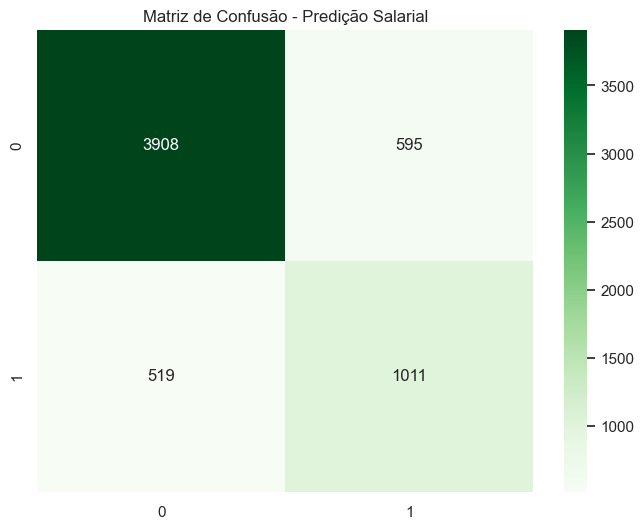

In [30]:
# =============================================
# TREINAMENTO DA MLP E REGISTRO DE MLOPS NO W&B
# =============================================
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import joblib

# 1. Divisão Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Normalização (Essencial para Redes Neurais não darem erro de convergência)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Definição da MLP
mlp = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, activation='relu', random_state=42)

print("Iniciando o treinamento da Rede Neural... Aguarde um instante.")
mlp.fit(X_train_scaled, y_train)

# 4. Avaliação
y_pred = mlp.predict(X_test_scaled)
f1 = f1_score(y_test, y_pred, average='weighted')

# 5. Gerar Matriz de Confusão para o Relatório
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusão - Predição Salarial')
plt.savefig("confusion_matrix.png")

# 6. Logar métricas no W&B
wandb.log({
    "f1_score_weighted": f1,
    "best_loss": mlp.best_loss_,
    "n_iter": mlp.n_iter_,
    "confusion_matrix": wandb.Image("confusion_matrix.png")
})

# 7. Salvar o Modelo como Artefato
model_filename = "mlp_salary_model.pkl"
joblib.dump(mlp, model_filename)
model_artifact = wandb.Artifact('trained_mlp_model', type='model')
model_artifact.add_file(model_filename)
wandb.log_artifact(model_artifact)

print(f"\nTreinamento concluído com sucesso! F1-Score: {f1:.4f}")
print(classification_report(y_test, y_pred))

wandb.finish() # Encerra a conexão com o W&B

## 4. Pipeline de MLOps e Versionamento (Weights & Biases)
Nesta seção, foi implementado o versionamento de experimentos e artefatos, uma prática Para garantir a reprodução do algoritmo e a governança do modelo. O uso da plataforma Weights & Biases (W&B) permite o rastreamento em tempo real de cada instância técnica ao qual foi realizado desde a concepção do projeto

In [ ]:
import wandb
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\josem\_netrc.
wandb: Currently logged in as: moiseslopesdasilva708811 (moiseslopesdasilva708811-ufrn) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
import pandas as pd
import numpy as np
import wandb
import joblib
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

run = wandb.init(
    project="salary-prediction-mlops",
    name="final-model-mlp",
    config={
        "hidden_layer_sizes": (64, 32), # Funil para extração das features
        "activation": "relu",          
        "solver": "adam",              
        "alpha": 0.0001,               
        "learning_rate_init": 0.001,
        "test_size": 0.2,              
        "random_state": 42
    }
)

# Salvando o dataset limpo que você gerou na etapa anterior
X_final.to_csv("X_selected_features.csv", index=False)
y.to_csv("y_target.csv", index=False)

data_artifact = wandb.Artifact('clean_dataset', type='dataset')
data_artifact.add_file('X_selected_features.csv')
run.log_artifact(data_artifact)

# ==========================================
# 3. SPLIT ESTRATIFICADO
# ==========================================
# O stratify=y é essencial para manter a proporção da classe 'salary'
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, 
    test_size=run.config.test_size, 
    stratify=y, 
    random_state=run.config.random_state
)

# ==========================================
# 4. TREINAMENTO COM EARLY STOPPING
# ==========================================
mlp = MLPClassifier(
    hidden_layer_sizes=run.config.hidden_layer_sizes,
    activation=run.config.activation,
    solver=run.config.solver,
    learning_rate_init=run.config.learning_rate_init,
    max_iter=500,
    early_stopping=True,     # MANDATÓRIO: Para evitar overfitting
    validation_fraction=0.1, # 10% do treino vira validação para o early stopping
    random_state=run.config.random_state,
    verbose=True
)

print("Iniciando treinamento da MLP...")
mlp.fit(X_train, y_train)

# ==========================================
# 5. AVALIAÇÃO E LOG DE MÉTRICAS
# ==========================================
y_pred = mlp.predict(X_test)
f1 = f1_score(y_test, y_pred, average='weighted')

# Gerar Matriz de Confusão para o Relatório
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusão - Predição Salarial')
plt.savefig("confusion_matrix.png")

# Logar métricas no W&B
wandb.log({
    "f1_score_weighted": f1,
    "best_loss": mlp.best_loss_,
    "n_iter": mlp.n_iter_,
    "confusion_matrix": wandb.Image("confusion_matrix.png")
})

print(f"\nTreinamento concluído! F1-Score: {f1:.4f}")
print(classification_report(y_test, y_pred))

model_filename = "mlp_salary_model.pkl"
joblib.dump(mlp, model_filename)

model_artifact = wandb.Artifact('trained_mlp_model', type='model')
model_artifact.add_file(model_filename)
run.log_artifact(model_artifact)

# Finalizar Run
run.finish()

NameError: name 'X_final' is not defined

Com esses conjunto de dados analisados, o próximo indicativo estudado na biblioteca pandas foi a limpeza de dados faltantes, onde foi utilizado um método chamado df.isin(["?"]).sum() que encontra valores nulos, ou seja, valores que não foram digitados e depois por meio do comando df.isnull().sum() apaga a existência desses dados nulos no conjunto, para facilitar uma análise mais aprofundada posteriormente com muito mais organização para saber qual dado interfere mais em outro dado, nessa base mais específica, como que um dado interfere mais no salário de uma pessoa nessas informações e como devem ser analisadas de ponto a ponto sem faltar informações cruciais sobre os indivíduos em questão, garantindo a integridade dos dados estudados.

## Análise de Correlação entre Variáveis

Segui 3 modos no gráfico de correlação, com esses passos:

- Valores próximos de **1** indicam uma forte correlação positiva entre os dados
- Valores próximos de **-1** indicam uma forte correlação negativa entre os dados
- Valores próximos de **0** indicam uma baixa ou nenhuma correlação entre os dados

C:\Users\josem\AppData\Local\Temp\ipykernel_11168\1494437750.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_clean.select_dtypes(include=['object']).columns:


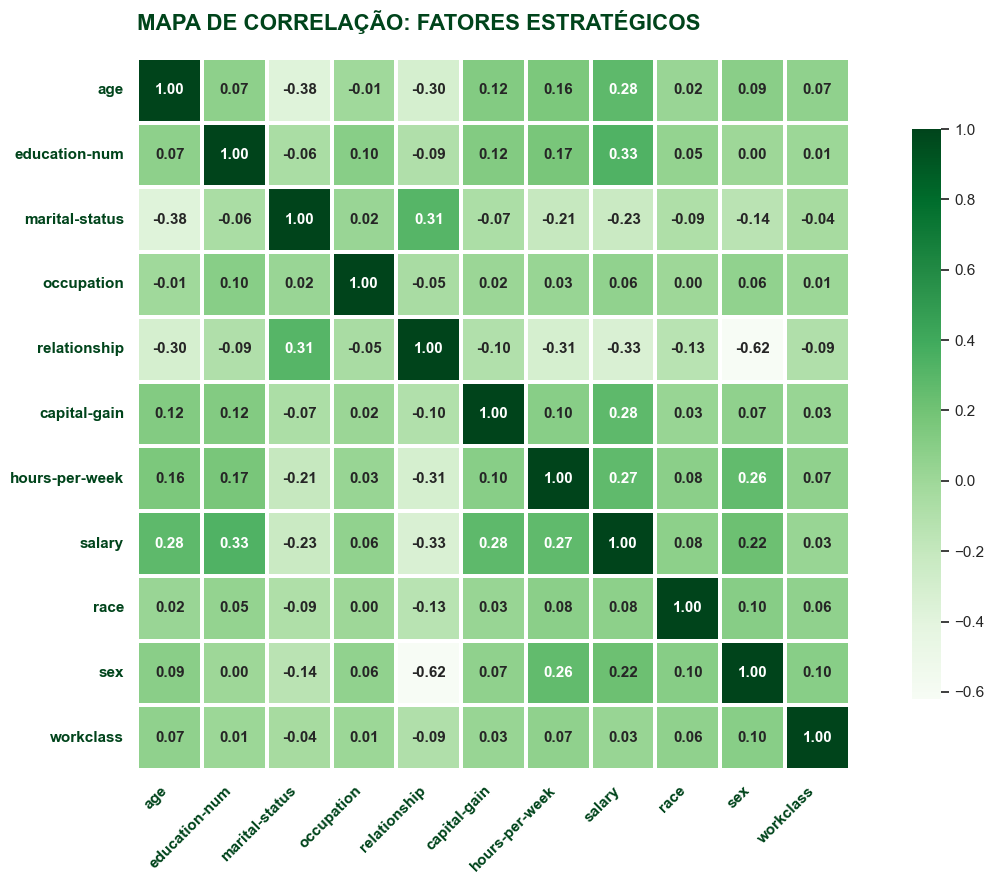

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import numpy as np

# O que dá o monex
cols_essenciais = [
    'age', 'education-num', 'marital-status', 'occupation', 
    'relationship', 'capital-gain', 'hours-per-week', 'salary',
    'race', 'sex', 'workclass'
]
df_clean = df[cols_essenciais].copy()

# 2. Encoding (Transformando texto em número pro gráfico entender)
le = LabelEncoder()
for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

# 3. Correlação de Spearman
corr_matrix = df_clean.corr(method='spearman')

# Gráfico verde para dá o tchan
plt.figure(figsize=(13, 9))
sns.set_theme(style="white") # Fundo branco pro verde destacar

# cmap='Greens' é VERDE PURO. Sem erro.
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='Greens',        # AGORA SIM: Verde claro ao Verde escuro
            annot_kws={"size": 11, "weight": "bold"}, 
            linewidths=1.5, 
            linecolor='white',    # Linha branca entre os blocos (elegância)
            square=True, 
            cbar_kws={"shrink": .8})

# Estética Final
plt.title("MAPA DE CORRELAÇÃO: FATORES ESTRATÉGICOS", 
          fontsize=16, fontweight='bold', pad=20, loc='left', color='#00441b')

plt.xticks(rotation=45, ha='right', fontsize=11, fontweight='bold', color='#00441b')
plt.yticks(fontsize=11, fontweight='bold', color='#00441b')

# Limpando as bordas
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig("heatmap_total_verde.png", dpi=300)
plt.show()

## Pré-processamento dos Dados

Decidi rodar um pré-processamento básico para dar uma limpada nos dados antes de jogar na rede neural

### Remoção de Duplicatas
Identifiquei e e removi registros duplicados presentes no dataset, a fim de evitar redundâncias. O comando utilizado foi o df.drop_duplicates(), ajudando a remover valores que pudessem enviesar o treinamento do modelo em questão.

### Tratamento de Valores Faltantes
Inicialmente, realizei a análise da proporção de valores ausentes em cada variável. Colunas que apresentaram mais de 50% de valores faltantes foram removidas, por terem capacidade de comprometer a qualidade da informação. Para as demais, será aplicada imputação de valores, utilizando estratégias como média, mediana, moda ou valor constante, de acordo com a distribuição dos dados.

### Tratamento de Outliers
Os valores discrepantes (OUTLIERS) foram identificados utilizando métodos estatísticos como o Intervalo Interquartil (IQR) ou o Z-score. Essa etapa visou reduzir o impacto de valores extremos que pudessem prejudicar a convergência da rede neural.

### Normalização e Padronização dos Dados
As variáveis numéricas foram normalizadas e padronizadas para melhorar a manipulação dos dados, utilizando técnicas como Min-Max Scaling ou StandardScaler. 

Essa sem dúvidas foi um etapa essencial para o treinamento do modelo, pois redes neurais são sensíveis à escala dos dados, e a padronização dos dados no Dataset contribuiu para uma convergência mais eficiente durante todo o treinamento.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler

df = pd.read_csv("C:/Users/josem/OneDrive/Documentos/MLOPs_Salary_Prediction/salary.csv") #Carregamento inicial dos dados


# =-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
# SHAPE ORIGINAL (ANTES DE REMOVER AS DUPLICATAS
# =-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=

print("Formal original:", df.shape) #Formato antes de remover as duplicatas

df = df.drop_duplicates() # Esse comando utilizei para remover duplicatas

# =-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
#COMANDO UTILIZADO PARA REMOVER DUPLICATAS
# =-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=

print("Após remover duplicatas:", df.shape) # Formato após a remoção das duplicatas


# Substituir "?" por NaN (muito comum em datasets)
df.replace("?", np.nan, inplace=True) # Para valores não cadastrados devidamente na base de dados

# Percentual de valores faltantes
missing_percent = df.isnull().mean() * 100
print("\nPercentual de valores faltantes:\n", missing_percent)

# Remover colunas com mais de 50% de missing
cols_to_drop = missing_percent[missing_percent > 50].index
df.drop(columns=cols_to_drop, inplace=True)
print("\nColunas removidas (>50% missing):", list(cols_to_drop))

# Separar colunas numéricas e categóricas
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object', 'string']).columns

# Imputação numérica pelo método da MEDIANA
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# =-=-=-=-=-=-=-=-=-=
# Imputação categórica MODA
# =-=-=-=-=-=-=-=-=-=
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nValores faltantes após tratamento:\n", df.isnull().sum())

# =========================
# 4. Tratamento de outliers (IQR)
# =========================

def remove_outliers_iqr(df, cols):
    df_clean = df.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

    return df_clean

df = remove_outliers_iqr(df, num_cols)
print("Após remoção de outliers:", df.shape)

# =========================
# 5. Normalização / Padronização
# =========================

# Escolha: StandardScaler (recomendado para MLP)
scaler = StandardScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])

print("\nDados normalizados com StandardScaler.")

# =========================
# Resultado final
# =========================
print("\nShape final:", df.shape)
print("\nPreview final:")
print(df.head())

Shape original: (32561, 15)
Após remover duplicatas: (32537, 15)

Percentual de valores faltantes:
 age               0.0
workclass         0.0
fnlwgt            0.0
education         0.0
education-num     0.0
marital-status    0.0
occupation        0.0
relationship      0.0
race              0.0
sex               0.0
capital-gain      0.0
capital-loss      0.0
hours-per-week    0.0
native-country    0.0
salary            0.0
dtype: float64

Colunas removidas (>50% missing): []

Valores faltantes após tratamento:
 age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
salary            0
dtype: int64
Após remoção de outliers: (18991, 15)

Dados normalizados com StandardScaler.

Shape final: (18991, 15)

Preview final:
        age          workclass    fnlwgt   educ

## Feature Importance

In [15]:
# =========================================================
# CÉLULA INTEGRADA: CODIFICAÇÃO + SELEÇÃO + TREINO
# =========================================================
import wandb
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.neural_network import MLPClassifier

# 1. Garantir que o df existe (O erro NameError: 'df' ocorre se não rodar o carregamento)
# Se o seu df sumiu, você precisa rodar a célula de read_csv lá em cima de novo!

# 2. Codificação do Alvo e Atributos
le = LabelEncoder()
df['salary'] = le.fit_transform(df['salary']) # Transforma >50k em 1 e <=50k em 0

# Transforma texto em número (Aqui que o X e y aparecem)
df_final = pd.get_dummies(df, drop_first=True)

X = df_final.drop('salary', axis=1)
y = df_final['salary']

# 3. Inicializar W&B 
wandb.init(project="MLOps_Salary_Prediction", name="pipeline_completo_final", reinit=True)

# 4. Seleção de Variáveis
rf = RandomForestClassifier(n_estimators=50, random_state=42) # n_estimators menor para ir mais rápido
rf.fit(X, y)
mi_scores = mutual_info_classif(X, y, random_state=42)

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_,
    'mi_score': mi_scores
}).sort_values(by='importance', ascending=False)

wandb.log({"feature_importance_table": wandb.Table(dataframe=importance_df)})

# 5. Split e Normalização (Prevenção de Data Leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Treino da MLP
print("Treinando a Rede Neural... Aguarde.")
mlp = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=300, random_state=42)
mlp.fit(X_train_scaled, y_train)

# 7. Log final
wandb.log({"f1_score": mlp.score(X_test_scaled, y_test)})
wandb.finish()

print("PROCESSO CONCLUÍDO COM SUCESSO!")

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Treinando a Rede Neural... Aguarde.


f1_score,▁
f1_score,0.81535


PROCESSO CONCLUÍDO COM SUCESSO!


In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
import wandb

# Reabre a sessão que "caiu"
wandb.init(project="MLOps_Salary_Prediction", name="finalizacao_metricas", reinit=True)

In [14]:
# =============================================
# TREINAMENTO DA MLP E REGISTRO DE MLOPS NO W&B
# =============================================
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import joblib

# 1. Divisão Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Normalização (Essencial para Redes Neurais não darem erro de convergência)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Definição da MLP
mlp = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, activation='relu', random_state=42)

print("Iniciando o treinamento da Rede Neural... Aguarde um instante.")
mlp.fit(X_train_scaled, y_train)

# 4. Avaliação
y_pred = mlp.predict(X_test_scaled)
f1 = f1_score(y_test, y_pred, average='weighted')

# 5. Gerar Matriz de Confusão para o Relatório
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusão - Predição Salarial')
plt.savefig("confusion_matrix.png")

# 6. Logar métricas no W&B
wandb.log({
    "f1_score_weighted": f1,
    "best_loss": mlp.best_loss_,
    "n_iter": mlp.n_iter_,
    "confusion_matrix": wandb.Image("confusion_matrix.png")
})

# 7. Salvar o Modelo como Artefato
model_filename = "mlp_salary_model.pkl"
joblib.dump(mlp, model_filename)
model_artifact = wandb.Artifact('trained_mlp_model', type='model')
model_artifact.add_file(model_filename)
wandb.log_artifact(model_artifact)

print(f"\nTreinamento concluído com sucesso! F1-Score: {f1:.4f}")
print(classification_report(y_test, y_pred))

wandb.finish() # Encerra a conexão com o W&B

NameError: name 'X' is not defined

## 4. Pipeline de MLOps e Versionamento (Weights & Biases)
Nesta seção, foi implementado o versionamento de experimentos e artefatos, uma prática Para garantir a reprodução do algoritmo e a governança do modelo. O uso da plataforma Weights & Biases (W&B) permite o rastreamento em tempo real de cada instância técnica ao qual foi realizado desde a concepção do projeto

In [3]:
import wandb
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\josem\_netrc.
wandb: Currently logged in as: moiseslopesdasilva708811 (moiseslopesdasilva708811-ufrn) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [13]:
import pandas as pd
import numpy as np
import wandb
import joblib
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

run = wandb.init(
    project="salary-prediction-mlops",
    name="final-model-mlp",
    config={
        "hidden_layer_sizes": (64, 32), # Funil para extração das features
        "activation": "relu",          
        "solver": "adam",              
        "alpha": 0.0001,               
        "learning_rate_init": 0.001,
        "test_size": 0.2,              
        "random_state": 42
    }
)

# Salvando o dataset limpo que você gerou na etapa anterior
X_final.to_csv("X_selected_features.csv", index=False)
y.to_csv("y_target.csv", index=False)

data_artifact = wandb.Artifact('clean_dataset', type='dataset')
data_artifact.add_file('X_selected_features.csv')
run.log_artifact(data_artifact)

# ==========================================
# 3. SPLIT ESTRATIFICADO
# ==========================================
# O stratify=y é essencial para manter a proporção da classe 'salary'
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, 
    test_size=run.config.test_size, 
    stratify=y, 
    random_state=run.config.random_state
)

# ==========================================
# 4. TREINAMENTO COM EARLY STOPPING
# ==========================================
mlp = MLPClassifier(
    hidden_layer_sizes=run.config.hidden_layer_sizes,
    activation=run.config.activation,
    solver=run.config.solver,
    learning_rate_init=run.config.learning_rate_init,
    max_iter=500,
    early_stopping=True,     # MANDATÓRIO: Para evitar overfitting
    validation_fraction=0.1, # 10% do treino vira validação para o early stopping
    random_state=run.config.random_state,
    verbose=True
)

print("Iniciando treinamento da MLP...")
mlp.fit(X_train, y_train)

# ==========================================
# 5. AVALIAÇÃO E LOG DE MÉTRICAS
# ==========================================
y_pred = mlp.predict(X_test)
f1 = f1_score(y_test, y_pred, average='weighted')

# Gerar Matriz de Confusão para o Relatório
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusão - Predição Salarial')
plt.savefig("confusion_matrix.png")

# Logar métricas no W&B
wandb.log({
    "f1_score_weighted": f1,
    "best_loss": mlp.best_loss_,
    "n_iter": mlp.n_iter_,
    "confusion_matrix": wandb.Image("confusion_matrix.png")
})

print(f"\nTreinamento concluído! F1-Score: {f1:.4f}")
print(classification_report(y_test, y_pred))

model_filename = "mlp_salary_model.pkl"
joblib.dump(mlp, model_filename)

model_artifact = wandb.Artifact('trained_mlp_model', type='model')
model_artifact.add_file(model_filename)
run.log_artifact(model_artifact)

# Finalizar Run
run.finish()

NameError: name 'X_final' is not defined